In [1]:
pip install scanpy anndata pandas scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install openpyxl

In [3]:
file_path_FSHS1_1 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487556_FSHD1.1.txt"
file_path_FSHS1_2 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487557_FSHD1.2.txt"
file_path_FSHS2_1 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487558_FSHD2.1.txt"
file_path_FSHS2_2 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487559_FSHD2.2.txt"
file_path_ctr1 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487560_CTRL.1.txt"
file_path_ctr2 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487561_CTRL.2.txt"

In [ ]:
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse

# load matrix
file_path = file_path_FSHS1_1
counts_gene_by_cell = pd.read_csv(
    file_path,
    sep="\t",
    index_col=0
)


counts_gene_by_cell.index = counts_gene_by_cell.index.astype(str).str.replace('"', '', regex=False)
counts_gene_by_cell.columns = counts_gene_by_cell.columns.astype(str).str.replace('"', '', regex=False)

# 3. 转置成 Scanpy/AnnData 需要的格式：cells × genes
counts_cell_by_gene = counts_gene_by_cell.T

# 4. 建立 AnnData object
adata = ad.AnnData(
    X=sparse.csr_matrix(counts_cell_by_gene.values),
    obs=pd.DataFrame(index=counts_cell_by_gene.index),
    var=pd.DataFrame(index=counts_cell_by_gene.columns)
)

# 5. 加上 sample 信息
adata.obs["sample"] = "FSHD1.1"

# 6. 保存原始 counts
adata.layers["counts"] = adata.X.copy()

# 7. 确保基因名唯一
adata.var_names_make_unique()

print(adata)

AnnData object with n_obs × n_vars = 2245 × 33694
    obs: 'sample'
    layers: 'counts'


In [5]:
import numpy as np

In [6]:
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse

def read_count_matrix(file_path, sample_name):
    counts = pd.read_csv(file_path, sep="\t", index_col=0)

    counts.index = counts.index.astype(str).str.replace('"', '', regex=False)
    counts.columns = counts.columns.astype(str).str.replace('"', '', regex=False)

    counts = counts.T  # cells × genes

    adata = ad.AnnData(
        X=sparse.csr_matrix(counts.values),
        obs=pd.DataFrame(index=counts.index),
        var=pd.DataFrame(index=counts.columns)
    )

    adata.obs["sample"] = sample_name
    adata.layers["counts"] = adata.X.copy()
    adata.var_names_make_unique()

    return adata


adata1 = read_count_matrix(file_path_FSHS1_1, "FSHD1.1")
adata2 = read_count_matrix(file_path_FSHS1_2, "FSHD1.2")
adata3 = read_count_matrix(file_path_FSHS2_1, "FSHD2.1")
adata4 = read_count_matrix(file_path_FSHS2_2, "FSHD2.2")
adata5 = read_count_matrix(file_path_ctr1, "CTR1")
adata6 = read_count_matrix(file_path_ctr2, "CTR2")

# 合并多个样本
adata = ad.concat(
    [adata1, adata2, adata3, adata4,adata5, adata6],
    label="sample_batch",
    keys=["FSHD1.1", "FSHD1.2","FSHD2.1","FSHD2.2","CTR1","CTR2"],
    join="outer",
    index_unique="-",
    fill_value=0
)

print(adata)
adata.write_h5ad("combined_raw_counts.h5ad")



AnnData object with n_obs × n_vars = 7047 × 33694
    obs: 'sample', 'sample_batch'
    layers: 'counts'


AnnData object with n_obs × n_vars = 7047 × 33694
    obs: 'sample', 'sample_batch'
    layers: 'counts'
                           sample sample_batch
AAACATACTATGCG-1-FSHD1.1  FSHD1.1      FSHD1.1
AAACATTGGCGAAG-1-FSHD1.1  FSHD1.1      FSHD1.1
AAACATTGTGAAGA-1-FSHD1.1  FSHD1.1      FSHD1.1
AAACCGTGTGTTTC-1-FSHD1.1  FSHD1.1      FSHD1.1
AAACGCACCTGCAA-1-FSHD1.1  FSHD1.1      FSHD1.1


C:\Users\Tanya\AppData\Local\Temp\ipykernel_50064\2120443500.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("sample_batch")[["total_counts", "n_genes_by_counts"]].describe()


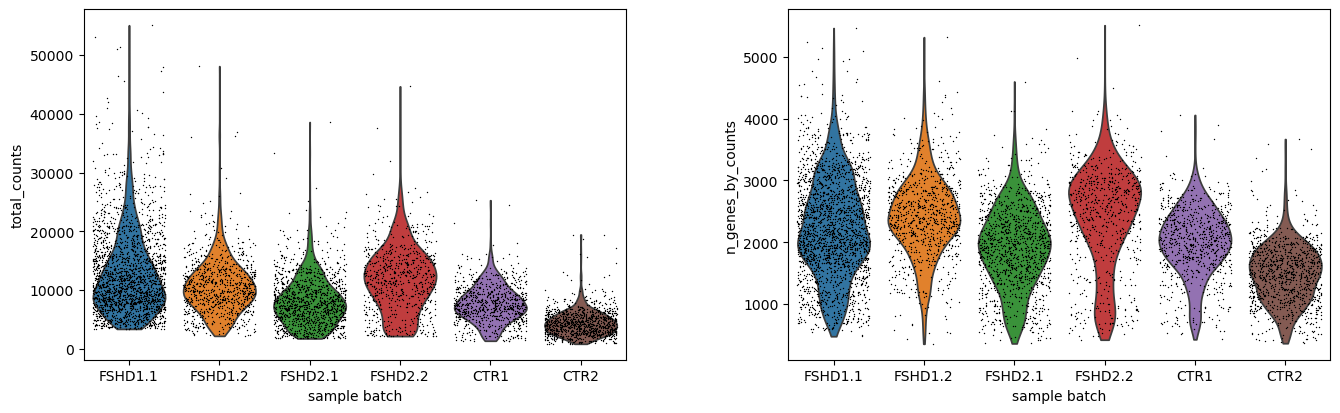

In [7]:
adata = sc.read_h5ad("combined_raw_counts.h5ad")

# 确保 cell names / gene names 唯一
adata.obs_names_make_unique()
adata.var_names_make_unique()

print(adata)
print(adata.obs.head())

sc.pp.calculate_qc_metrics(
    adata,
    inplace=True
)


adata.obs.groupby("sample_batch")[["total_counts", "n_genes_by_counts"]].describe()
sc.pl.violin(
    adata,
    ["total_counts", "n_genes_by_counts"],
    groupby="sample_batch",
    jitter=0.4,
    multi_panel=True
)

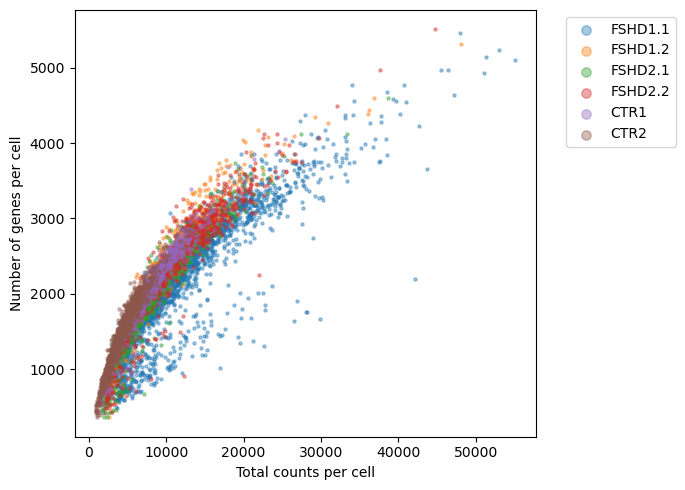

C:\Users\Tanya\AppData\Local\Temp\ipykernel_50064\569852325.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["total_counts"].corr(x["n_genes_by_counts"], method="spearman"))


sample_batch
FSHD1.1    0.904163
FSHD1.2    0.959738
FSHD2.1    0.967815
FSHD2.2    0.947967
CTR1       0.973387
CTR2       0.970566
dtype: float64

In [8]:
import matplotlib.pyplot as plt

samples = adata.obs["sample_batch"].unique()
# correlation between number of genes and total counts
plt.figure(figsize=(7, 5))

for sample in samples:
    sub = adata.obs[adata.obs["sample_batch"] == sample]
    plt.scatter(
        sub["total_counts"],
        sub["n_genes_by_counts"],
        s=5,
        alpha=0.4,
        label=sample
    )

plt.xlabel("Total counts per cell")
plt.ylabel("Number of genes per cell")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

corr_by_sample = (
    adata.obs
    .groupby("sample_batch", observed=True)
    .apply(lambda x: x["total_counts"].corr(x["n_genes_by_counts"], method="spearman"))
)

corr_by_sample

In [9]:

# Summarize QC metrics by sample
qc_summary = (
    adata.obs
    .groupby("sample_batch", observed=True)[["total_counts", "n_genes_by_counts"]]
    .quantile([0.01, 0.05, 0.50, 0.95, 0.99])
)

qc_summary

total_counts  n_genes_by_counts
sample_batch                                      
FSHD1.1      0.01       3630.68             679.16
             0.05       4479.60             918.40
             0.50      11297.00            2175.00
             0.95      26536.60            3539.40
             0.99      37297.92            4274.20
FSHD1.2      0.01       2705.93             802.41
             0.05       4023.05            1246.20
             0.50      10208.50            2399.00
             0.95      18128.75            3470.05
             0.99      25304.10            4047.16
FSHD2.1      0.01       1876.44             543.61
             0.05       2541.45             759.70
             0.50       7557.00            1932.50
             0.95      15082.50            2890.95
             0.99      20215.66            3463.13
FSHD2.2      0.01       2255.33             551.18
             0.05       2854.05             778.40
             0.50      11797.00            2567.50
             0.95      20935.80            3456.90
             0.99      26275.27            3998.80
CTR1         0.01       1483.84             644.44
             0.05       2673.60             937.00
             0.50       7431.00            2036.00
             0.95      12933.20            2790.00
             0.99      15871.80            3102.48
CTR2         0.01       1021.00             461.00
             0.05       1637.00             744.00
             0.50       4217.00            1504.00
             0.95       7847.00            2163.00
             0.99      11756.00            2765.00

In [28]:
# QC:

# Make a copy before filtering
adata_qc = adata.copy()

# Calculate QC metrics if not already calculated
sc.pp.calculate_qc_metrics(adata_qc, inplace=True)

# Basic lower thresholds
# Remove cells with very low RNA capture
min_genes = 700
min_counts = 2200

adata_qc = adata_qc[
    (adata_qc.obs["n_genes_by_counts"] > min_genes) &
    (adata_qc.obs["total_counts"] > min_counts),
    :
].copy()


print("Before filtering:", adata.n_obs, "cells")
print("After upper filtering:", adata_qc.n_obs, "cells")

Before filtering: 7047 cells
After upper filtering: 6771 cells


In [62]:
# copy for normalization
adata_norm = adata_qc.copy()

# Store raw counts before normalization
adata_norm.layers["counts"] = adata_norm.X.copy()

# Normalize each cell to the same total count
sc.pp.normalize_total(
    adata_norm,
    target_sum=1e4
)

# Log-transform the normalized data
sc.pp.log1p(adata_norm)

# Store log-normalized data
adata_norm.layers["lognorm"] = adata_norm.X.copy()

adata_norm.write_h5ad("combined_qc_normalized.h5ad")




# Calculate mean expression for each gene
X = adata_norm.X

if sparse.issparse(X):
    gene_means = np.asarray(X.mean(axis=0)).ravel()
else:
    gene_means = X.mean(axis=0)

# Get top 10 expressed genes
top_gene_idx = np.argsort(gene_means)[-10:][::-1]
top_genes = adata_norm.var_names[top_gene_idx]

print(top_genes)



Index(['ENSG00000140988', 'ENSG00000167996', 'ENSG00000198804',
       'ENSG00000167526', 'ENSG00000231500', 'ENSG00000147403',
       'ENSG00000142541', 'ENSG00000100316', 'ENSG00000137818',
       'ENSG00000105372'],
      dtype='object')


In [30]:
# Add Ensembl ID column from adata gene names
adata_norm.var["ensembl_id"] = (
    adata_norm.var_names
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
    .str.replace(r"\.\d+$", "", regex=True)
)



In [31]:
# Load DUX4-67 gene set
file_path_DUX4_geneset = r"C:\Users\Tanya\Desktop\RNA sequencing\ddu251supp_table3.xlsx"

# Read Excel file
dux4_df = pd.read_excel(file_path_DUX4_geneset,header=1,engine="openpyxl")

# Extract Ensembl id from the DUX4-67 gene set
dux4_67_ensg = (
    dux4_df["ENSEMBL"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.replace(r"\.\d+$", "", regex=True)  # remove version number if present
    .unique()
    .tolist()
)

# Find DUX4-67 genes present in target dataset
dux4_genes_present = [
    gene for gene in dux4_67_ensg
    if gene in set(adata_norm.var["ensembl_id"])
]

print("DUX4-67 genes in file:", len(dux4_67_ensg))
print("DUX4-67 genes found in adata:", len(dux4_genes_present))


DUX4-67 genes in file: 67
DUX4-67 genes found in adata: 43


In [32]:
#caculate the number of biomakers expresseed by cells


X_counts = adata_norm.layers["counts"]

# Get gene indices of DUX4-67 genes
dux4_gene_idx = np.where(
    adata_norm.var["ensembl_id"].isin(dux4_genes_present)
)[0]

# Extract raw counts of DUX4-67 genes
dux4_counts = X_counts[:, dux4_gene_idx]

# Count how many DUX4 biomarkers are expressed in each cell
if sparse.issparse(dux4_counts):
    adata_norm.obs["n_DUX4_targets_expressed"] = np.asarray(
        (dux4_counts > 0).sum(axis=1)
    ).ravel()
else:
    adata_norm.obs["n_DUX4_targets_expressed"] = (dux4_counts > 0).sum(axis=1)

adata_norm.obs["n_DUX4_targets_expressed"].describe()

count    6771.000000
mean        0.185202
std         1.040378
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        29.000000
Name: n_DUX4_targets_expressed, dtype: float64

count = 6954
现在总共有 6954 个细胞。
mean = 0.167
平均每个细胞只表达 0.167 个 DUX4 biomarker，说明 DUX4 特征很少见。
25%, 50%, 75% 都是 0
至少 75% 的细胞一个 DUX4 biomarker 都没表达。这个很正常，因为 DUX4-affected cells 本来就是很小的一群。
max = 29
有些细胞最多表达了 29 个 DUX4 biomarker，说明这些细胞很可能是 DUX4-affected cells

In [33]:
# Define DUX4-affected cells
adata_norm.obs["DUX4_affected"] = adata_norm.obs["n_DUX4_targets_expressed"] >= 5
adata_norm.obs["DUX4_affected"].value_counts()

# caculate counts of MYH3
myh3_ensg = "ENSG00000109063"

myh3_idx = np.where(adata_norm.var["ensembl_id"] == myh3_ensg)[0]

if len(myh3_idx) == 0:
    raise ValueError("MYH3 Ensembl ID was not found in adata.")

myh3_counts = X_counts[:, myh3_idx[0]]

if sparse.issparse(myh3_counts):
    myh3_counts = np.asarray(myh3_counts.todense()).ravel()
else:
    myh3_counts = np.asarray(myh3_counts).ravel()

adata_norm.obs["MYH3_counts"] = myh3_counts



In [34]:
# > 1 read 
if sparse.issparse(dux4_counts):
    adata_norm.obs["n_DUX4_targets_expressed"] = np.asarray(
        (dux4_counts > 0).sum(axis=1)
    ).ravel()
else:
    adata_norm.obs["n_DUX4_targets_expressed"] = (
        dux4_counts > 0
    ).sum(axis=1)


# Initialize all cells as Other
adata_norm.obs["cell_classification"] = "Other"

# DUX4-affected cells:
# Cells expressing at least 5 DUX4-67 biomarkers
# Each biomarker is counted as expressed if raw count >= 1 read
adata_norm.obs.loc[
    adata_norm.obs["n_DUX4_targets_expressed"] >= 5,
    "cell_classification"
] = "DUX4-affected"

# Non-affected late myocytes:
# Cells with MYH3 raw counts >= 5
# and fewer than 5 expressed DUX4-67 biomarkers
adata_norm.obs.loc[
    (adata_norm.obs["MYH3_counts"] >= 5) &
    (adata_norm.obs["n_DUX4_targets_expressed"] < 5),
    "cell_classification"
] = "Non-affected late myocytes"


# Total number of cells in the current AnnData object
print("Total cell count:", adata_norm.n_obs)

# Count cells in each classification group
print(adata_norm.obs["cell_classification"].value_counts())


Total cell count: 6771
cell_classification
Other                         3525
Non-affected late myocytes    3217
DUX4-affected                   29
Name: count, dtype: int64


In [35]:
# Check cell classification numbers
classification_summary = pd.crosstab(
    adata_norm.obs["sample_batch"],
    adata_norm.obs["cell_classification"]
)

classification_summary

cell_classification,DUX4-affected,Non-affected late myocytes,Other
sample_batch,,,
FSHD1.1,13,737,1464
FSHD1.2,2,522,356
FSHD2.1,12,577,633
FSHD2.2,2,359,326
CTR1,0,500,284
CTR2,0,522,462


In [39]:
adata_de = adata_norm.copy()

# Use log-normalized data for differential expression
adata_de.X = adata_de.layers["lognorm"].copy()

In [40]:
# differential analysis

# Define FSHD samples
fshd_samples = ["FSHD1.1", "FSHD1.2", "FSHD2.1", "FSHD2.2"]

def run_de_for_sample(adata, sample_name):
    # Keep one sample and the two cell classes used for DE
    sub = adata[
        (adata.obs["sample_batch"] == sample_name) &
        (adata.obs["cell_classification"].isin([
            "DUX4-affected",
            "Non-affected late myocytes"
        ]))
    ].copy()
    
    # Remove unused categories
    sub.obs["cell_classification"] = sub.obs["cell_classification"].astype("category")
    sub.obs["cell_classification"] = sub.obs["cell_classification"].cat.remove_unused_categories()
    
    # Count cells in each group
    group_counts = sub.obs["cell_classification"].value_counts()
    
    print("\nSample:", sample_name)
    print(group_counts)
    
    
    # Check minimum cell number
    if group_counts["DUX4-affected"] < 2:
        print("Skipped: DUX4-affected group has fewer than 2 cells.")
        return None
    
    if group_counts["Non-affected late myocytes"] < 2:
        print("Skipped: reference group has fewer than 2 cells.")
        return None
    
    # Run Wilcoxon differential expression analysis
    sc.tl.rank_genes_groups(
        sub,
        groupby="cell_classification",
        groups=["DUX4-affected"],
        reference="Non-affected late myocytes",
        method="wilcoxon",
        corr_method="benjamini-hochberg",
        use_raw=False
    )
    
    # Convert result to dataframe
    de_df = sc.get.rank_genes_groups_df(
        sub,
        group="DUX4-affected"
    )
    
    de_df = de_df.rename(columns={"names": "gene_id"})
    de_df["sample"] = sample_name
    
    return de_df


de_results = []

for sample in fshd_samples:
    result = run_de_for_sample(adata_de, sample)
    if result is not None:
        de_results.append(result)

de_per_sample = pd.concat(de_results, ignore_index=True)



Sample: FSHD1.1
cell_classification
Non-affected late myocytes    737
DUX4-affected                  13
Name: count, dtype: int64

Sample: FSHD1.2
cell_classification
Non-affected late myocytes    522
DUX4-affected                   2
Name: count, dtype: int64

Sample: FSHD2.1
cell_classification
Non-affected late myocytes    577
DUX4-affected                  12
Name: count, dtype: int64

Sample: FSHD2.2
cell_classification
Non-affected late myocytes    359
DUX4-affected                   2
Name: count, dtype: int64


In [41]:
for sample in fshd_samples:
    sub = de_per_sample[de_per_sample["sample"] == sample]
    print(sample)
    print("raw p < 0.05:", (sub["pvals"] < 0.05).sum())
    print("adj p < 0.05:", (sub["pvals_adj"] < 0.05).sum())

FSHD1.1
raw p < 0.05: 736
adj p < 0.05: 11
FSHD1.2
raw p < 0.05: 209
adj p < 0.05: 0
FSHD2.1
raw p < 0.05: 711
adj p < 0.05: 39
FSHD2.2
raw p < 0.05: 350
adj p < 0.05: 0


In [42]:
#Wilcoxon Rank Sum Test; BH FDR-corrected P-value < 0.05
# Keep significant differentially expressed genes

de_per_sample_sig = de_per_sample[
    de_per_sample["pvals_adj"] < 0.05
].copy()




In [43]:
# Create significant gene sets for each sample
sig_gene_sets = {}

for sample in fshd_samples:
    genes = set(
        de_per_sample_sig.loc[
            de_per_sample_sig["sample"] == sample,
            "gene_id"
        ]
    )
    sig_gene_sets[sample] = genes

# Check number of significant genes per sample
for sample, genes in sig_gene_sets.items():
    print(sample, len(genes))

FSHD1.1 11
FSHD1.2 0
FSHD2.1 39
FSHD2.2 0


In [ ]:
# Genes significant in FSHD1 samples but not in FSHD2 samples
fshd1_specific = (
    sig_gene_sets["FSHD1.1"] |
    sig_gene_sets["FSHD1.2"]
) - (
    sig_gene_sets["FSHD2.1"] |
    sig_gene_sets["FSHD2.2"]
)

print("FSHD1-specific genes:", len(fshd1_specific))

FSHD1-specific genes: 6


In [ ]:
# Genes significant in FSHD2 samples but not in FSHD1 samples
fshd2_specific = (
    sig_gene_sets["FSHD2.1"] |
    sig_gene_sets["FSHD2.2"]
) - (
    sig_gene_sets["FSHD1.1"] |
    sig_gene_sets["FSHD1.2"]
)

print("FSHD2-specific genes:", len(fshd2_specific))

FSHD2-specific genes: 34


In [61]:

# Load gene annotation table
annotation_path = r"C:\Users\Tanya\Desktop\RNA sequencing\gencode.v49.basic.annotation.gff3"

# GFF3 standard column names
gff_cols = [
    "seqid", "source", "type", "start", "end",
    "score", "strand", "phase", "attributes"
]

# Read GFF3 file and skip comment lines
gff = pd.read_csv(
    annotation_path,
    sep="\t",
    comment="#",
    header=None,
    names=gff_cols,
    low_memory=False
)

# Keep only gene-level annotation
genes = gff[gff["type"] == "gene"].copy()

# Extract Ensembl gene ID and gene symbol
genes["gene_id"] = genes["attributes"].str.extract(r"(?:^|;)gene_id=([^;]+)")
genes["gene_name"] = genes["attributes"].str.extract(r"(?:^|;)gene_name=([^;]+)")

# Clean Ensembl ID: remove version number, e.g. ENSG00000106853.18 -> ENSG00000106853
genes["gene_id_clean"] = (
    genes["gene_id"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.\d+$", "", regex=True)
)

# Build annotation table
annotation = (
    genes[["gene_id_clean", "gene_name"]]
    .dropna()
    .drop_duplicates()
)

# Create mapping dictionary: clean Ensembl ID -> gene symbol
id_to_symbol = dict(zip(annotation["gene_id_clean"], annotation["gene_name"]))

# Convert a gene set to a dataframe and add gene symbols
def annotate_gene_set(gene_set, id_to_symbol, gene_set_name):
    # Convert set to dataframe
    df = pd.DataFrame({
        "ensembl_id": sorted(list(gene_set))
    })
    
    # Clean Ensembl ID in the gene set
    df["ensembl_id_clean"] = (
        df["ensembl_id"]
        .astype(str)
        .str.strip()
        .str.replace(r"\.\d+$", "", regex=True)
    )
    
    # Map Ensembl ID to gene symbol
    df["gene_symbol"] = df["ensembl_id_clean"].map(id_to_symbol)
    
    # Add gene set name
    df.insert(0, "gene_set", gene_set_name)
    
    return df




In [63]:
# Annotate FSHD1-specific and FSHD2-specific gene sets
fshd1_specific_df = annotate_gene_set(
    fshd1_specific,
    id_to_symbol,
    "FSHD1-specific"
)

fshd2_specific_df = annotate_gene_set(
    fshd2_specific,
    id_to_symbol,
    "FSHD2-specific"
)

print(fshd1_specific_df)
print(fshd2_specific_df)

         gene_set       ensembl_id ensembl_id_clean gene_symbol
0  FSHD1-specific  ENSG00000106853  ENSG00000106853       PTGR1
1  FSHD1-specific  ENSG00000107745  ENSG00000107745       MICU1
2  FSHD1-specific  ENSG00000119986  ENSG00000119986       AVPI1
3  FSHD1-specific  ENSG00000122257  ENSG00000122257       RBBP6
4  FSHD1-specific  ENSG00000138079  ENSG00000138079      SLC3A1
5  FSHD1-specific  ENSG00000158186  ENSG00000158186        MRAS
          gene_set       ensembl_id ensembl_id_clean gene_symbol
0   FSHD2-specific  ENSG00000059804  ENSG00000059804      SLC2A3
1   FSHD2-specific  ENSG00000081189  ENSG00000081189       MEF2C
2   FSHD2-specific  ENSG00000100142  ENSG00000100142      POLR2F
3   FSHD2-specific  ENSG00000100811  ENSG00000100811         YY1
4   FSHD2-specific  ENSG00000108106  ENSG00000108106       UBE2S
5   FSHD2-specific  ENSG00000109063  ENSG00000109063        MYH3
6   FSHD2-specific  ENSG00000110801  ENSG00000110801       PSMD9
7   FSHD2-specific  ENSG00000112

In [52]:
# Save annotated gene sets
fshd1_specific_df.to_csv(
    "FSHD1_specific_reconstructed_with_gene_symbols.csv",
    index=False
)

fshd2_specific_df.to_csv(
    "FSHD2_specific_reconstructed_with_gene_symbols.csv",
    index=False
)